# ST-GNN Model Evaluation & Comparison Graphs

This notebook evaluates the Spatio-Temporal Graph Neural Network (ST-GNN) snow water equivalent (SWE) predictions against multiple reference sources:

- **DHSVM** – Distributed Hydrology Soil Vegetation Model
- **UCLA** – UCLA SWE product
- **UA** – University of Arizona (mean_swe)
- **ERA5** – ECMWF reanalysis
- **SNODAS** – NOAA Snow Data Assimilation System
- **LiDAR** – aggregated HUC12 LiDAR SWE (Olympic)

It loads ST-GNN time-split test results, aggregates SWE by basin (Cedar, Green, Snohomish, Stillaguamish), and produces time-series comparison plots and peak-SWE (April 1) comparisons.

## Imports

In [ ]:
# import libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import r2_score
import boto3
from io import StringIO
from io import BytesIO
from snowML.datapipe.utils import get_geos as gg
from snowML.datapipe.utils import data_utils as du


## Plot style and constants

Colors, line widths, and plot labels for each SWE source (DHSVM, UCLA, UA, ERA5, SNODAS, ST-GNN, LiDAR).

In [145]:

# =========================
# Colors / style
# =========================
FIG_COLORS = {
    "DHSVM": "#666666",      # darker gray
    "UCLA": "#cf5f2c",     # more dark, magenta
    "UA": "#4287f5",         # blue
    "ERA5": "#43b77a",       # greenish teal
    "SNODAS": "#edae49",     # gold/yellow
    "ST-GNN": "#9a47ff",      # rich orange/red 
    "LiDAR": "black"       # forest green
}

PEAK_COLOR = "#D8B5E8"

LINE_WIDTHS = {
    "DHSVM": 1.0,
    "UCLA": 1.0,
    "UA": 0.9,
    "ERA5": 0.9,
    "SNODAS": 0.9,
    "ST-GNN": 0.9
}

ALPHAS = {
    "DHSVM": 0.7,
    "UCLA": 0.7,
    "UA": 0.7,
    "ERA5": 0.7,
    "SNODAS": 0.7,
    "ST-GNN": 0.8,
    "LiDAR": 0.9
}

PLOT_LABELS = {
    "mean_swe": "UA",
    "era5_swe": "ERA5",
    "snodas_swe": "SNODAS",
    "model_pred": "ST-GNN",
    "DHSVM": "DHSVM",
    "UCLA": "UCLA",
    "LiDAR": "LiDAR"
}


## Basin configuration

URLs and filenames for each evaluation basin: Cedar, Green, Snohomish, Stillaguamish (DHSVM, UCLA, and shapefile keys).

In [146]:
# define constants/urls/filenames
cedar_dict = {
    "name": "Cedar",
    "url": "https://data.cig.uw.edu/picea/mauger/misc/wrf_run_agg/Aggregated.Values_Cedar",
    "dhsvm_shape_key": "hsvm_cedar.geojson",
    "dhsvm_huc_key": "hucs_match_hsvm_cedar.geojson", 
    "UCLA_file_nm": "mean_swe_ucla_2_in_Cedar.csv"
}

green_dict = {
    "name": "Green", 
    "url": "https://data.cig.uw.edu/picea/mauger/misc/wrf_run_agg/Aggregated.Values_Green",
    "dhsvm_shape_key": "hsvm_green.geojson",
    "dhsvm_huc_key": "hucs_match_hsvm_green.geojson", 
    "UCLA_file_nm": "mean_swe_ucla_2_in_green.csv"
}

snoho_dict = {
    "name": "Snohomish",
    "url": "https://data.cig.uw.edu/picea/mauger/misc/wrf_run_agg/Aggregated.Values_Snohomish", 
    "dhsvm_shape_key": "hsvm_snoho.geojson",
    "dhsvm_huc_key": "hucs_match_hsvm_snoho.geojson", 
    "UCLA_file_nm": "mean_swe_ucla_2_in_snoho.csv"
}

stilly_dict = {
    "name": "Stilly",
    "dhsvm_huc_key": "hucs_match_hsvm_stilly.geojson",
    "url": "https://data.cig.uw.edu/picea/mauger/misc/wrf_run_agg/Aggregated.Values_Stilliguamish", 
    "UCLA_file_nm": "mean_swe_ucla_2_in_stilly.csv" # reconstructed from hucs
}


## Config / paths

Model output CSV, S3 bucket names, and local CSV paths for DHSVM/LiDAR HUCs and LiDAR SWE.

In [ ]:
# =========================
# Config
# =========================
MODEL_RESULTS_BUCKET = "spatiotemporal-results"
MODEL_OUTPUT_CSV = "stgnn/temporal_split/st_gnn_time_split_test_results_all_runs.csv.gz"
MODEL_READY_BUCKET = "snowml-model-ready-stgnn"
UCLA_S3_BUCKET = "snowml-gold"

DHSVM_LIDAR_HUCS_CSV = "dhsvm_lidar_hucs.csv"
LIDAR_SWE_CSV = "lidar_swe_huc12_aggregated_olympic.csv"


## Load Model Outputs

In [ ]:
s3 = boto3.client('s3')

In [ ]:
obj = s3.get_object(Bucket=MODEL_RESULTS_BUCKET, Key=MODEL_OUTPUT_CSV)
model_pred_df = pd.read_csv(BytesIO(obj["Body"].read()), compression="gzip")
model_pred_df["huc_id"] = model_pred_df["huc_id"].astype(str)

if "date" in model_pred_df.columns:
    model_pred_df["date"] = pd.to_datetime(model_pred_df["date"])
elif "day" in model_pred_df.columns:
    model_pred_df["day"] = pd.to_datetime(model_pred_df["day"])

if "day" in model_pred_df.columns:
    last_date = model_pred_df["day"].max()
    END_DATE  = last_date - pd.DateOffset(years=1)
    BEGIN_DATE = END_DATE - pd.DateOffset(years=6)
else:
    raise ValueError("Expected column 'day' not found in model_pred_df")

## Helper Functions

In [110]:
def filter_by_date(df, begin_date, end_date):
    """Filter DataFrame by date range. df must have datetime index."""
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    begin_date = pd.to_datetime(begin_date)
    end_date = pd.to_datetime(end_date)
    return df[(df.index >= begin_date) & (df.index <= end_date)]


def get_huc_area(huc_id):
    """Get HUC12 area in square meters (projected to epsg=26910)."""
    geos = gg.get_geos_with_name(str(huc_id), '12')
    geos_proj = geos.to_crs(epsg=26910)
    return geos_proj.geometry.iloc[0].area

**Load DHSVM data from URL.** Reads CSV from the given URL and sets the first column as a datetime index (used for basin-level DHSVM SWE).

**Load GeoJSON shapefile from S3.** Loads basin or HUC geometry from `snowml-shape` (used for spatial joins and mapping).

In [111]:
def load_dhsvm_data(url): 
    tem = pd.read_csv(url, sep = '\\s+' )
    tem.set_index(pd.DatetimeIndex(tem.iloc[:, 0]), inplace = True)
    return tem

In [112]:
def load_shape(key):
    s3_url = f's3://snowml-shape/{key}'
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        gdf = gpd.read_file(f"s3://snowml-shape/{key}", storage_options={'anon': False}) 
    return gdf


**Aggregate LIDAR SWE by basin.** For a list of HUC12 IDs, loads LIDAR SWE from the Olympic CSV, filters to the evaluation date range.

In [113]:
def aggregate_lidar_swe_by_basin(huc_list, lidar_csv_path=LIDAR_SWE_CSV):
    """
    Area-weighted aggregate of LIDAR SWE from lidar_swe_huc12_aggregated_olympic.csv
    for a list of HUCs. Returns Series with index=date, values=basin mean lidar_swe (m).
    """
    lidar_df = pd.read_csv(lidar_csv_path)
    lidar_df["date"] = pd.to_datetime(lidar_df["date"])
    huc_strs = [str(h) for h in huc_list]
    lidar_df = lidar_df[lidar_df["huc_id"].astype(str).isin(huc_strs)]
    if lidar_df.empty:
        return pd.Series(dtype=float)
    begin = pd.to_datetime(BEGIN_DATE)
    end = pd.to_datetime(END_DATE)
    lidar_df = lidar_df[(lidar_df["date"] >= begin) & (lidar_df["date"] <= end)]
    if lidar_df.empty:
        return pd.Series(dtype=float)
    areas = {}
    for h in huc_list:
        try:
            areas[str(h)] = get_huc_area(h)
        except Exception:
            pass
    lidar_df["area"] = lidar_df["huc_id"].astype(str).map(areas)
    lidar_df = lidar_df[lidar_df["area"].notna() & (lidar_df["area"] > 0)]
    if lidar_df.empty:
        return pd.Series(dtype=float)
    lidar_df["weighted"] = lidar_df["mean_lidar_swe"] * lidar_df["area"]
    agg = lidar_df.groupby("date").agg({"weighted": "sum", "area": "sum"})
    agg["lidar_swe"] = agg["weighted"] / agg["area"]
    return agg["lidar_swe"]

**Aggregate model-ready and ST-GNN predictions by basin.** Loads per-HUC CSVs from S3, filters by date, and returns area-weighted daily series for UA (`mean_swe`), ERA5, SNODAS, and ST-GNN `pred_mean`.

In [114]:
def aggregate_model_ready_by_basin(huc_list, swe_cols=["mean_swe", "era5_swe", "snodas_swe"]):
    """
    Area-weighted aggregate of model_ready SWE columns for a list of HUCs.
    Returns dict: {col: Series with index=day, basin mean}.
    """
    results = {c: [] for c in swe_cols}
    areas_used = {}
    for huc_id in huc_list:
        try:
            area = get_huc_area(huc_id)
        except Exception as e:
            print(f"Skip huc {huc_id}: {e}")
            continue
        key = f"model_ready_huc{huc_id}.csv"
        try:
            df = du.s3_to_df(key, MODEL_READY_BUCKET)
        except Exception as e:
            print(f"Skip {key}: {e}")
            continue
        df["day"] = pd.to_datetime(df["day"])
        df = df.set_index("day")
        df = filter_by_date(df, BEGIN_DATE, END_DATE)
        areas_used[huc_id] = area
        for c in swe_cols:
            if c in df.columns:
                results[c].append((df[[c]] * area, area))
    tot_area = sum(areas_used.values()) if areas_used else 0
    # n_hucs_loaded = len(areas_used)
    out = {}
    for c in swe_cols:
        if not results[c] or tot_area == 0:
            continue
        # # For era5_swe: include only if every loaded HUC had it (ignore ERA5 for basin if any HUC missing)
        # if c == "era5_swe" and len(results[c]) != n_hucs_loaded:
        #     continue
        parts = [p[0] for p in results[c]]
        merged = pd.concat(parts, axis=1)
        out[c] = merged.sum(axis=1, skipna=False) / tot_area
    return out


def aggregate_model_pred_by_basin(model_df, huc_list):
    """Area-weighted aggregate of pred_mean for basin HUCs."""
    model_df = model_df.copy()
    model_df["date"] = pd.to_datetime(model_df["day"])
    huc_strs = [str(h) for h in huc_list]
    model_df = model_df[model_df["huc_id"].astype(str).isin(huc_strs)]
    if model_df.empty:
        return pd.Series(dtype=float)
    areas = {}
    for h in huc_list:
        try:
            areas[str(h)] = get_huc_area(h)
        except Exception:
            pass
    model_df["area"] = model_df["huc_id"].astype(str).map(areas)
    model_df = model_df[model_df["area"].notna() & (model_df["area"] > 0)]
    if model_df.empty:
        return pd.Series(dtype=float)
    model_df["weighted"] = model_df["pred_mean"] * model_df["area"]
    agg = model_df.groupby("date").agg({"weighted": "sum", "area": "sum"})
    agg["pred_mean"] = agg["weighted"] / agg["area"]
    agg = filter_by_date(agg[["pred_mean"]], BEGIN_DATE, END_DATE)
    return agg["pred_mean"]
    

**Load DHSVM and UCLA SWE for a basin.** `load_dhsvm_basin` fetches DHSVM data, resamples to daily, and filters to the evaluation window. `load_ucla_basin` loads UCLA SWE from `snowml-gold` and filters by date.

In [115]:
def load_dhsvm_basin(my_dict):
    """Load DHSVM SWE for basin, resample to daily, filter by date."""
    dhsvm = load_dhsvm_data(my_dict["url"])
    dhsvm_swe = dhsvm[["Swq"]].resample("D").mean()
    dhsvm_swe = dhsvm_swe.rename(columns={"Swq": "mean_swe"})
    return filter_by_date(dhsvm_swe, BEGIN_DATE, END_DATE)


def load_ucla_basin(my_dict):
    """Load UCLA SWE for basin from snowml-gold (same as CompareSWESources calc_UCLA)."""
    f = my_dict["UCLA_file_nm"]
    df = du.s3_to_df(f, UCLA_S3_BUCKET)
    df = df.set_index("day")
    df.index = pd.to_datetime(df.index)
    if "SWE_Post" in df.columns:
        df = df.rename(columns={"SWE_Post": "mean_swe"})
    return filter_by_date(df[["mean_swe"]], BEGIN_DATE, END_DATE)



In [136]:
def plot_basin_sources(series_list, title, save=False, fname=None):
    """
    Clean plotting for SWE comparison.
    Lines are thin and light so overlaps are visible.
    """

    plt.figure(figsize=(12,6))

    for s in series_list:

        x = pd.to_datetime(s["x"])
        y = s["y"]

        color = s.get("color", None)
        lw = s.get("lw", 1.2)
        alpha = s.get("alpha", 0.7)

        if s.get("scatter", False):
            plt.scatter(
                x,
                y,
                label=s["label"],
                color=color,
                s=20,
                alpha=0.8,
                zorder=5
            )
        else:
            plt.plot(
                x,
                y,
                label=s["label"],
                color=color,
                linewidth=lw,
                alpha=alpha,
                zorder=2
            )

    plt.title('', fontsize=14)
    plt.ylabel("SWE (m)", fontsize=18)
    plt.xlabel("Date", fontsize=18)

    plt.grid(alpha=0.25)

    plt.legend(fontsize=16, frameon=False)

    ax = plt.gca()
    ax.tick_params(axis='x', labelsize=18)   # year labels
    ax.tick_params(axis='y', labelsize=16)   # SWE values
    ax.xaxis.set_major_locator(mdates.YearLocator(1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()

    if save:
        plt.savefig(fname if fname else f"{title}.png", dpi=300)

    plt.show()

# Load Model Output and Basin Mapping

In [131]:
# Load basin -> HUC mapping (use path relative to notebook or absolute)
DHSVM_BASINS = ['cedar', 'green', 'snohomish', 'stilly']
LIDAR_BASINS = ['lidar']
try:
    hucs = pd.read_csv(DHSVM_LIDAR_HUCS_CSV)
except FileNotFoundError:
    hucs = pd.read_csv("dhsvm_lidar_hucs.csv")  # if running from STGNN dir

dhsvm_hucs = hucs[hucs['basin'].isin(DHSVM_BASINS)]
lidar_hucs = hucs[hucs['basin'].isin(LIDAR_BASINS)]

#basin_dicts = [cedar_dict, green_dict, snoho_dict, stilly_dict]
basin_dicts = [snoho_dict]

### LIDAR Basins

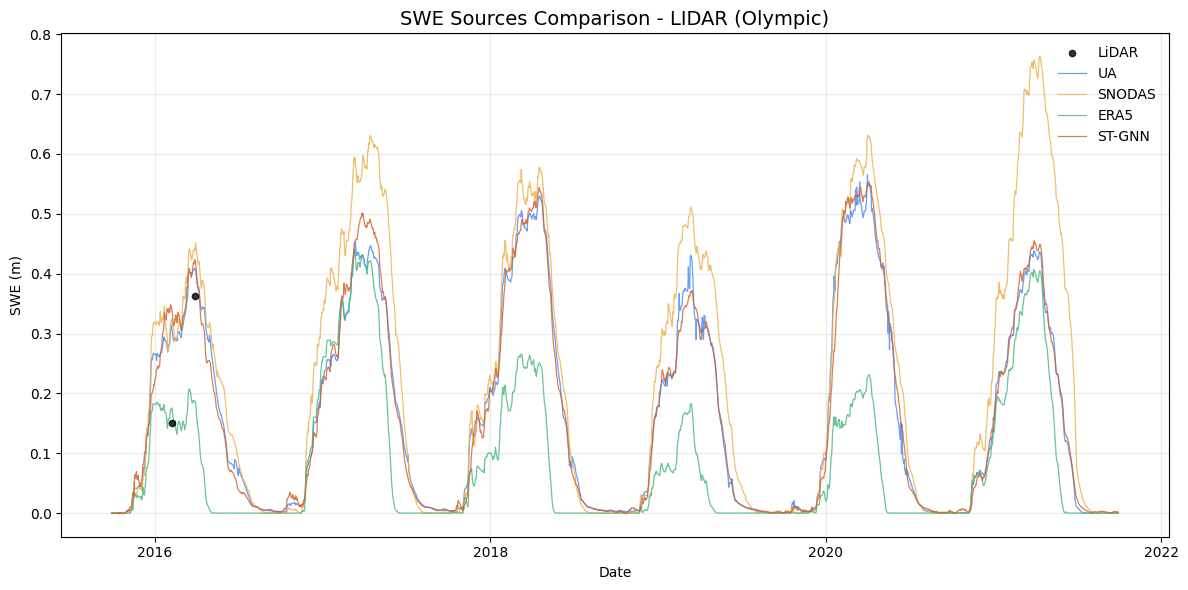

In [118]:
# =========================
# Plot LIDAR basin
# =========================
lidar_huc_list = lidar_hucs["huc_id"].astype(str).tolist()

if lidar_huc_list:
    series_list_lidar = []

    lidar_agg = aggregate_lidar_swe_by_basin(lidar_huc_list)
    if not lidar_agg.empty:
        series_list_lidar.append({
            "x": lidar_agg.index,
            "y": lidar_agg.values,
            "label": PLOT_LABELS["LiDAR"],
            "color": FIG_COLORS["LiDAR"],
            "scatter": True,
            "alpha": ALPHAS["LiDAR"]
        })

    mr_agg_lidar = aggregate_model_ready_by_basin(
        lidar_huc_list,
        swe_cols=("mean_swe", "era5_swe", "snodas_swe")
    )

    for col in ("mean_swe", "snodas_swe", "era5_swe"):
        if col in mr_agg_lidar and not mr_agg_lidar[col].empty:
            label = PLOT_LABELS[col]
            series_list_lidar.append({
                "x": mr_agg_lidar[col].index,
                "y": mr_agg_lidar[col].values,
                "label": label,
                "color": FIG_COLORS[label],
                "lw": LINE_WIDTHS[label],
                "alpha": ALPHAS[label]
            })

    # model predictions
    pred_series = aggregate_model_pred_by_basin(model_pred_df, lidar_huc_list)
    if not pred_series.empty:
        label = PLOT_LABELS["model_pred"]
        series_list_lidar.append({
            "x": pred_series.index,
            "y": pred_series.values,
            "label": label,
            "color": FIG_COLORS[label],
            "lw": LINE_WIDTHS[label],
            "alpha": ALPHAS[label]
        })

    if series_list_lidar:
        plot_basin_sources(
            series_list_lidar,
            "SWE Sources Comparison - LIDAR (Olympic)",
            save=False
        )
else:
    print("No LIDAR HUCs found in mapping.")

### Plot DHSVM basins

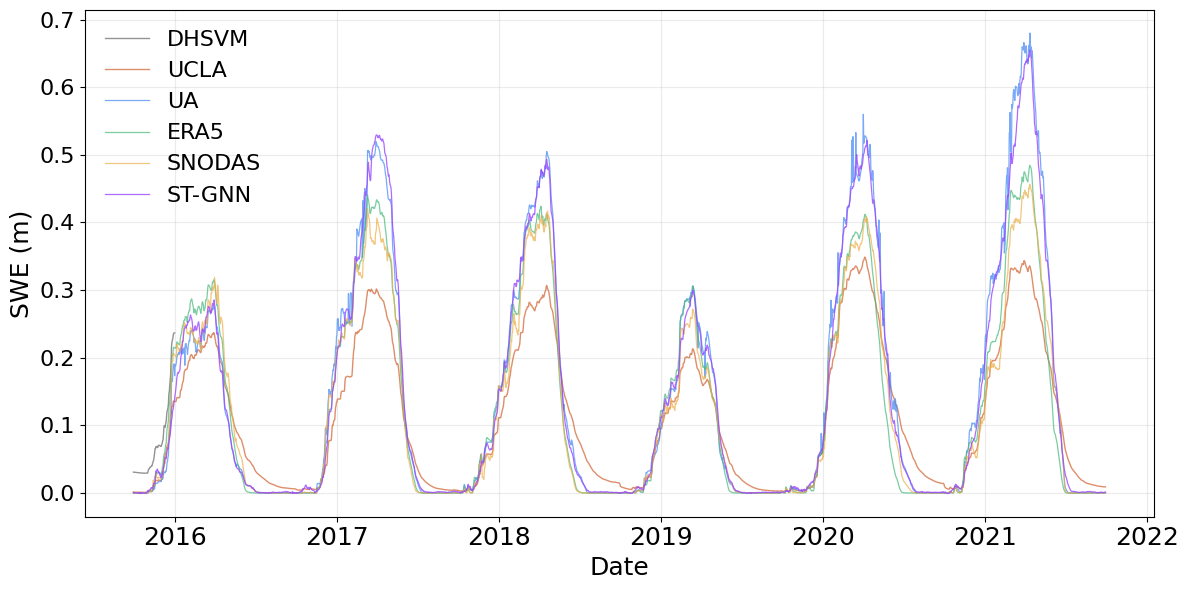

In [137]:
# =========================
# Plot DHSVM basins
# =========================
for my_dict in basin_dicts:
    name = my_dict["name"]

    huc_list = (
        dhsvm_hucs[dhsvm_hucs["basin"].str.lower() == name.lower()]["huc_id"]
        .astype(str)
        .tolist()
    )

    if not huc_list:
        print(f"No HUCs for {name}, skip")
        continue

    series_list = []

    # 1. DHSVM
    dhsvm_df = load_dhsvm_basin(my_dict)
    if not dhsvm_df.empty:
        series_list.append({
            "x": dhsvm_df.index,
            "y": dhsvm_df["mean_swe"].values,
            "label": "DHSVM",
            "color": FIG_COLORS["DHSVM"],
            "lw": LINE_WIDTHS["DHSVM"],
            "alpha": ALPHAS["DHSVM"]
        })

    # 2. UCLA
    try:
        ucla_df = load_ucla_basin(my_dict)
        if not ucla_df.empty:
            series_list.append({
                "x": ucla_df.index,
                "y": ucla_df["mean_swe"].values,
                "label": "UCLA",
                "color": FIG_COLORS["UCLA"],
                "lw": LINE_WIDTHS["UCLA"],
                "alpha": ALPHAS["UCLA"]
            })
    except Exception as e:
        print(f"UCLA skip for {name}: {e}")

    # 3-5. model-ready basin aggregation
    mr_agg = aggregate_model_ready_by_basin(huc_list)

    for col in ("mean_swe", "era5_swe", "snodas_swe"):
        if col in mr_agg and not mr_agg[col].empty:
            label = PLOT_LABELS[col]
            series_list.append({
                "x": mr_agg[col].index,
                "y": mr_agg[col].values,
                "label": label,
                "color": FIG_COLORS[label],
                "lw": LINE_WIDTHS[label],
                "alpha": ALPHAS[label]
            })

    # 6. model predictions
    pred_series = aggregate_model_pred_by_basin(model_pred_df, huc_list)
    if not pred_series.empty:
        label = PLOT_LABELS["model_pred"]
        series_list.append({
            "x": pred_series.index,
            "y": pred_series.values,
            "label": label,
            "color": FIG_COLORS[label],
            "lw": LINE_WIDTHS[label],
            "alpha": ALPHAS[label]
        })

    plot_basin_sources(
        series_list,
        f"SWE Sources Comparison - {name}",
        save=False
    )

## PLOT SWE PEAKS for different sources

In [ ]:
# Load UCLA April 1 SWE (2009-2022) from per-HUC CSVs - only HUCs whose data is present
huc_ids_all = model_pred_df["huc_id"].dropna().astype(str).unique().tolist()
ids_present = [h for h in huc_ids_all if du.isin_s3(UCLA_S3_BUCKET, f"mean_swe_ucla_2_in_{h}.csv")]

**Build UCLA April 1 SWE table.** For each HUC with UCLA data, extracts the SWE value on each April 1 from 2009–2022 and collects into a list, then builds a DataFrame of `(huc_id, day, ucla_swe)` for peak-SWE comparison.

In [ ]:
ucla_april1_list = []

for huc_id in ids_present:
    key = f"mean_swe_ucla_2_in_{huc_id}.csv"
    df = du.s3_to_df(key, UCLA_S3_BUCKET)
    if len(df) == 0:
        print(f"File is empty: {huc_id}")
        continue
    df["day"] = pd.to_datetime(df["day"]).dt.normalize()
    # print(df.head(2))
    # Ensure SWE column name is consistent
    if "SWE_Post" in df.columns:
        df = df.rename(columns={"SWE_Post": "ucla_swe"})

    if "ucla_swe" not in df.columns:
        continue

    df = df.set_index("day")

    april1_dates = pd.date_range("2009-04-01", "2022-04-01", freq="YS-APR")

    for d in april1_dates:
        if d in df.index:
            val = df.loc[d, "ucla_swe"]
            if isinstance(val, pd.Series):
                val = val.iloc[0]

            ucla_april1_list.append({
                "huc_id": huc_id,
                "day": d,
                "ucla_swe": val
            })

ucla_april1_df = pd.DataFrame(ucla_april1_list)

print(f"UCLA April 1: {len(ids_present)} HUCs with data, {len(ucla_april1_df)} (huc, April 1) points for 2009-2022")

File is empty: 171100050602
File is empty: 171100080201
UCLA April 1: 384 HUCs with data, 4966 (huc, April 1) points for 2009-2022


In [162]:
ucla_april1_df

,huc_id,day,ucla_swe
0,170200090101,2009-04-01,0.553462
1,170200090101,2010-04-01,0.588807
2,170200090101,2011-04-01,0.728164
3,170200090101,2012-04-01,0.752050
4,170200090101,2013-04-01,0.590179
...,...,...,...
4961,171100210201,2017-04-01,0.521408
4962,171100210201,2018-04-01,0.290836
4963,171100210201,2019-04-01,0.101473
4964,171100210201,2020-04-01,0.329696


### ALL BASINS

         huc_id        day  pred_run_1  pred_run_2  pred_run_3  pred_run_4  \
0  170103020101 2009-04-01         NaN         NaN         NaN         NaN   
1  170103020101 2010-04-01    0.193039    0.203008    0.193048    0.194167   

   pred_run_5  pred_mean  pred_std    ua_swe  era5_swe  snodas_swe  \
0         NaN        NaN       NaN       NaN       NaN         NaN   
1    0.198372   0.196327  0.003874  0.191818  0.262834         NaN   

  Predominant Snow  Mean Elevation  ucla_swe  
0              NaN             NaN  0.385357  
1   Montane Forest     1430.934082  0.150773  
626


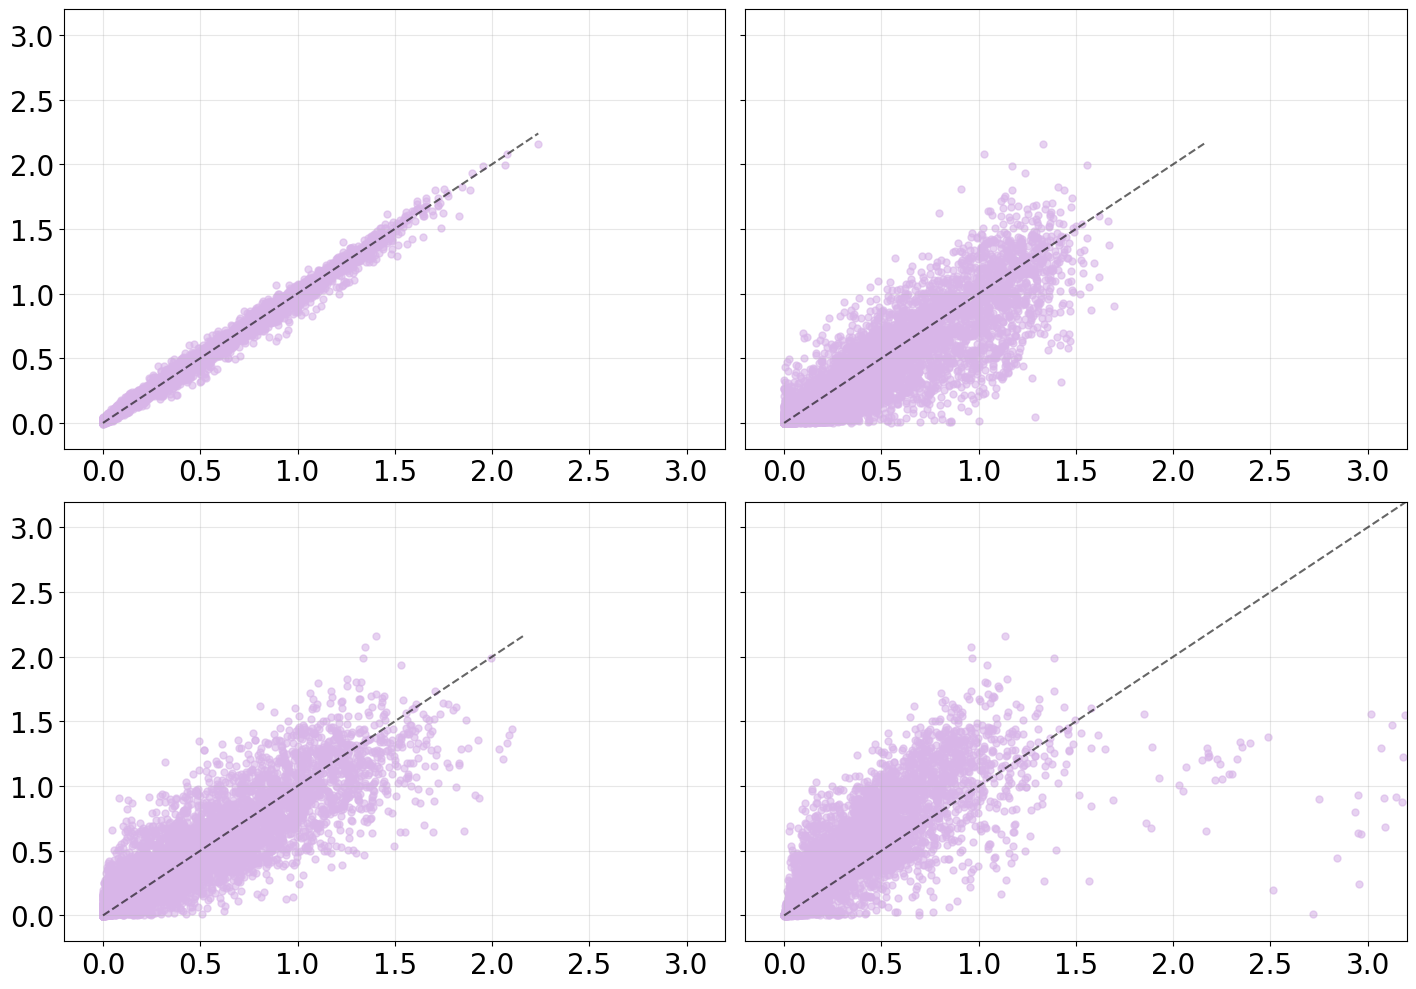

In [177]:
date_col = "day"
model_pred_df[date_col] = pd.to_datetime(model_pred_df[date_col])

april1 = model_pred_df[
    (model_pred_df[date_col].dt.month == 4) &
    (model_pred_df[date_col].dt.day == 1)
].copy()

new_df = april1.merge(
    ucla_april1_df,
    left_on=["huc_id", "day"],
    right_on=["huc_id", "day"],
    how="outer"
)
print(new_df.head(2))
print(len(new_df['huc_id'].unique()))

sources = {
    "UA": "ua_swe",
    "ERA5": "era5_swe",
    "SNODAS": "snodas_swe",
    "UCLA": "ucla_swe"
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()

for ax, (label, col) in zip(axes, sources.items()):
    valid = new_df[[col, "pred_mean"]].dropna()

    ax.scatter(
        valid[col],
        valid["pred_mean"],
        alpha=0.6,
        s=25,
        color=PEAK_COLOR
    )

    mx = max(valid[col].max(), valid["pred_mean"].max())
    ax.plot([0, mx], [0, mx], "k--", alpha=0.6)

    ax.set_title('')
    #ax.set_xlabel(f"{label} SWE", fontsize=18)
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
    ax.set_xlim(-0.2, 3.2)
    ax.set_ylim(-0.2, 3.2)
    ax.grid(True, alpha=0.3)

#plt.suptitle("Peak SWE (April 1): ST-GNN vs Different SWE Sources", fontsize=14)
# fig.supylabel("Predicted SWE (ST-GNN)", fontsize=20)
plt.tight_layout()
plt.show()

## Model Results

In [48]:
from sklearn.metrics import mean_squared_error, r2_score

def kling_gupta_efficiency(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    if np.isnan(y_true).any() or np.isnan(y_pred).any():
        return np.nan

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan

    r = np.corrcoef(y_true, y_pred)[0, 1]
    alpha = np.std(y_pred) / (np.std(y_true) + eps)

    mean_true = np.mean(y_true)
    if np.isclose(mean_true, 0.0):
        beta = np.nan
    else:
        beta = np.mean(y_pred) / (mean_true + eps)

    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    return kge

def compute_metrics(y_true, y_pred):
    """
    Compute evaluation metrics for SWE prediction.
    """

    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    if np.isnan(y_true).any() or np.isnan(y_pred).any():
        return {
            "mse": np.nan,
            "kge": np.nan,
            "r2": np.nan,
            "mean_error": np.nan,
            "median_error": np.nan,
            "iqr_error": np.nan
        }

    errors = y_pred - y_true

    q1 = np.percentile(errors, 25)
    q3 = np.percentile(errors, 75)

    return {
        "mse": mean_squared_error(y_true, y_pred),
        "kge": kling_gupta_efficiency(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }

**Compute per-HUC evaluation metrics.** Groups model predictions by `huc_id`, applies `compute_metrics(ua_swe, pred_mean)` to get MSE, KGE, and R² per HUC, and displays the results DataFrame.

In [49]:
results = (
    model_pred_df
    .groupby("huc_id")
    .apply(lambda df: compute_metrics(df["ua_swe"], df["pred_mean"]))
)
results_df = pd.DataFrame(results.tolist(), index=results.index)
results_df

/tmp/ipykernel_162298/958788604.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: compute_metrics(df["ua_swe"], df["pred_mean"]))


,mse,kge,r2
huc_id,,,
170103020101,0.000335,0.991740,0.987964
170103020102,0.000250,0.974298,0.987227
170103020103,0.000604,0.976211,0.970429
170103020201,0.000695,0.948959,0.964391
170103020202,0.000317,0.945769,0.964841
...,...,...,...
171100200509,0.000770,0.861580,0.961502
171100200510,0.000352,0.950534,0.981451
171100200511,0.000170,0.880862,0.942636


**Summary statistics over HUCs.** Computes mean, median, std, quartiles (q1, q3), and IQR for each metric (MSE, KGE, R²) across all HUCs and prints the summary table.

In [53]:
summary = {}

for metric in ["mse", "kge", "r2"]:
    
    vals = results_df[metric].dropna()

    q1 = vals.quantile(0.25)
    q3 = vals.quantile(0.75)

    summary[metric] = {
        "mean": vals.mean(),
        "median": vals.median(),
        "std": np.std(vals),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1
    }

summary_df = pd.DataFrame(summary).T
print(summary_df)

         mean    median       std        q1        q3       iqr
mse  0.000528  0.000233  0.000701  0.000068  0.000702  0.000634
kge  0.760921  0.961802  0.790022  0.844621  0.982420  0.137800
r2   0.874267  0.979110  0.272597  0.917321  0.989472  0.072151
